# Computer Exercise 13.1 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **챕터**: 13. Minimization of Functions  
> **절**: §13.1 One-Variable Case — **Successive Parabolic Interpolation**  
> **풀이 일자**: 2026-06-19 · **언어**: Python (NumPy/Pandas/Matplotlib)


## 1. 문제 (원문)

> Implement **successive parabolic interpolation** for minimizing a function of one variable. Given three points, fit a quadratic and take its vertex as the next estimate, then slide the window to the three most recent points. Apply it to $f(x)=x^4-14x^3+60x^2-70x$ with starting points in $[0,2]$. Compare the **number of function evaluations** with the golden section search of Problem 1, and discuss the attainable accuracy.

### 한국어 풀이용 정리
- **목표**: 세 점을 지나는 포물선의 꼭짓점을 다음 추정으로 삼아 최소점에 접근(도함수 불필요).
- **갱신**: 가장 최근 세 점 $(x_{n-2},x_{n-1},x_n)$ 으로 창(window)을 미끄러뜨린다.
- **확인 포인트**: (a) 황금분할 대비 *함수평가 격감*(초선형), (b) **평탄한 최소** 부근의 정밀도 한계($\sqrt{\varepsilon}$ 현상), (c) 단봉 가드 부재로 인한 불안정성.


## 2. 수학적 배경

세 점 $(x_0,f_0),(x_1,f_1),(x_2,f_2)$ 를 지나는 2차 보간의 꼭짓점:
$$\boxed{\;x_{\text{new}}=x_1-\frac12\,\frac{(x_1-x_0)^2\,[f_1-f_2]-(x_1-x_2)^2\,[f_1-f_0]}{(x_1-x_0)\,[f_1-f_2]-(x_1-x_2)\,[f_1-f_0]}\;}$$
분모는 곡률($2a$)에 비례. $a>0$ 일 때만 꼭짓점이 최소다.

**수렴 차수(이론)**: 최소 근방에서 $|e_{n+1}|\approx C|e_n|^{p}$, $p=1.3247\ldots$ (*plastic number*, $t^3=t+1$ 의 실근). 이는 Day 13 의 **secant**(order $1.618$)와 같은 계열의 *초선형* 수렴이며, 반복당 함수평가가 1회뿐이라 *평가당 효율*이 매우 좋다.

**평탄 최소의 정밀도 한계(핵심)**: 최소 근방에서 $f(x)\approx f^\*+\tfrac12 f''(x^\*)(x-x^\*)^2$ 이라 *함수값 차이*가 $O\big(f''\,\Delta x^2\big)$ 로 작다. $\tfrac12 f''\Delta x^2\lesssim \varepsilon|f^\*|$ 가 되면 세 함수값이 반올림 안에서 구분되지 않아 꼭짓점 공식이 무의미해진다 — 도함수를 쓰지 않는 모든 방법의 위치 정밀도가
$$\Delta x_{\min}\;\sim\;\sqrt{\tfrac{2\varepsilon|f^\*|}{|f''(x^\*)|}}\;\approx\;\mathcal{O}(\sqrt{\varepsilon})$$
수준에서 **바닥(floor)** 에 부딪힌다. (Problem 3 의 Newton 은 *평탄하지 않은* $f'(x)=0$ 을 풀므로 이 한계를 피한다.)


## 3. 풀이 흐름

1. 공통 $f$, $x^\*$ 를 불러온다.
2. 꼭짓점 공식 `vertex(...)` 구현(분모 0 가드).
3. `spi(...)`: 세 점에서 시작, 매 반복 꼭짓점 계산 후 **가장 최근 세 점**으로 창 이동, 오차 기록.
4. 초기 세 점 $0.0,1.0,2.0$ 으로 실행 — 오차 수열과 함수평가 수.
5. **함수평가 to tolerance** 표: golden vs SPI 를 tol $\in\{10^{-2},10^{-4},10^{-6}\}$ 에서 비교.
6. 도달 가능한 최소 오차(정밀도 바닥)를 관측하고 $\sqrt{\varepsilon}$ 추정과 대조.
7. (좌) 포물선 보간 과정, (우) 오차–평가비용 semilog 로 *초선형 vs 선형*과 *바닥* 시각화.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda v: f'{v:.6e}')

In [2]:
# 공통 시험함수: 고전 교재용 사차다항식
f   = lambda x: x**4 - 14*x**3 + 60*x**2 - 70*x
fp  = lambda x: 4*x**3 - 42*x**2 + 120*x - 70      # f'(x)
fpp = lambda x: 12*x**2 - 84*x + 120               # f''(x)  = 12(x-2)(x-5)

# 참조 최소점 x*: f'(x)=0 의 [0,2] 내 근을 Newton 으로 고정밀 계산
xs = 1.0
for _ in range(60):
    xs = xs - fp(xs)/fpp(xs)
XSTAR = xs           # 전역 최소 x*  (~0.7809)
FSTAR = f(XSTAR)

print(f'x* = {XSTAR:.12f}   f(x*) = {FSTAR:.12f}')

x* = 0.780884053088   f(x*) = -24.369601567355


In [3]:
# 황금분할(기준선) — 오차/평가 수열 반환
tau = (np.sqrt(5) - 1) / 2
def golden_trace(a, b, tol=1e-12, maxit=200):
    x1 = b - tau*(b-a); x2 = a + tau*(b-a); f1, f2 = f(x1), f(x2)
    nfev = 2; trace = []   # (nfev, err)
    for k in range(maxit):
        trace.append((nfev, abs(0.5*(a+b) - XSTAR)))
        if (b-a) < tol: break
        if f1 < f2:
            b, x2, f2 = x2, x1, f1; x1 = b - tau*(b-a); f1 = f(x1); nfev += 1
        else:
            a, x1, f1 = x1, x2, f2; x2 = a + tau*(b-a); f2 = f(x2); nfev += 1
    return trace


In [4]:
# 연속 포물선 보간 (sliding window of 3 most recent points)
def vertex(x0, x1, x2, f0, f1, f2):
    num = (x1-x0)**2*(f1-f2) - (x1-x2)**2*(f1-f0)
    den = (x1-x0)*(f1-f2) - (x1-x2)*(f1-f0)
    if abs(den) < 1e-300:
        return None
    return x1 - 0.5*num/den

def spi_trace(p0, p1, p2, maxit=25):
    x0, x1, x2 = p0, p1, p2
    f0, f1, f2 = f(x0), f(x1), f(x2)
    nfev = 3; rows = []; trace = []
    for k in range(1, maxit+1):
        xv = vertex(x0, x1, x2, f0, f1, f2)
        if xv is None or not np.isfinite(xv):
            break
        fv = f(xv); nfev += 1
        err = abs(xv - XSTAR)
        rows.append({'iter': k, 'x_vertex': xv, 'f_vertex': fv, 'err': err})
        trace.append((nfev, err))
        step = abs(xv - x2)            # 최근 추정과의 변화량
        x0, x1, x2 = x1, x2, xv        # 가장 최근 세 점으로 창 이동
        f0, f1, f2 = f1, f2, fv
        if step < 1e-13:               # 꼭짓점이 멈춤 = 정밀도 바닥 도달
            break
    return pd.DataFrame(rows), nfev, trace

dfp, nfev_p, trace_p = spi_trace(0.0, 1.0, 2.0)
floor_err = dfp['err'].min()
# sqrt(eps) 기반 정밀도 바닥 추정
eps = np.finfo(float).eps
dx_floor = np.sqrt(2*eps*abs(FSTAR)/fpp(XSTAR))
print('SPI (sliding window):')
print(f'  최종 x_vertex = {dfp["x_vertex"].iloc[-1]:.12f}')
print(f'  도달 최소 오차(바닥) = {floor_err:.3e}   함수평가 = {nfev_p}회')
print(f'  sqrt(eps) 정밀도 바닥 추정 ~ {dx_floor:.3e}  (도함수 없는 최소화의 한계)')
print(f'  비교: Newton(Problem 3)은 f\'=0 을 풀어 ~1e-16 까지 도달 (평탄하지 않음)')

SPI (sliding window):
  최종 x_vertex = 0.780884053118
  도달 최소 오차(바닥) = 2.951e-11   함수평가 = 14회
  sqrt(eps) 정밀도 바닥 추정 ~ 1.324e-08  (도함수 없는 최소화의 한계)
  비교: Newton(Problem 3)은 f'=0 을 풀어 ~1e-16 까지 도달 (평탄하지 않음)


In [5]:
# SPI 수렴표
dfp[['iter','x_vertex','f_vertex','err']]

,iter,x_vertex,f_vertex,err
0,1,9.600000e-01,-2.344096e+01,1.791159e-01
1,2,6.211853e-01,-2.353757e+01,1.596988e-01
2,3,7.830609e-01,-2.436946e+01,2.176863e-03
3,4,7.859419e-01,-2.436881e+01,5.057828e-03
4,5,7.810780e-01,-2.436960e+01,1.939336e-04
5,6,7.808819e-01,-2.436960e+01,2.191661e-06
6,7,7.808839e-01,-2.436960e+01,1.710493e-07
7,8,7.808841e-01,-2.436960e+01,1.185497e-10
8,9,7.808841e-01,-2.436960e+01,5.953171e-11
9,10,7.808841e-01,-2.436960e+01,2.950906e-11


In [6]:
# 함수평가 to tolerance 비교: golden vs SPI
tg = golden_trace(0.0, 2.0)
def evals_to(trace, tol):
    for nf, er in trace:
        if er < tol:
            return nf
    return None
tols = [1e-2, 1e-4, 1e-6]
cmp = pd.DataFrame({
    'tolerance': tols,
    'Golden_fevals':    [evals_to(tg, t) for t in tols],
    'Parabolic_fevals': [evals_to(trace_p, t) for t in tols],
})
cmp['speedup_x'] = cmp['Golden_fevals'] / cmp['Parabolic_fevals']
print('동일 정확도 도달에 필요한 함수평가 횟수 (적을수록 좋음):')
cmp

동일 정확도 도달에 필요한 함수평가 횟수 (적을수록 좋음):


,tolerance,Golden_fevals,Parabolic_fevals,speedup_x
0,1.000000e-02,8,6,1.333333e+00
1,1.000000e-04,14,9,1.555556e+00
2,1.000000e-06,27,10,2.700000e+00


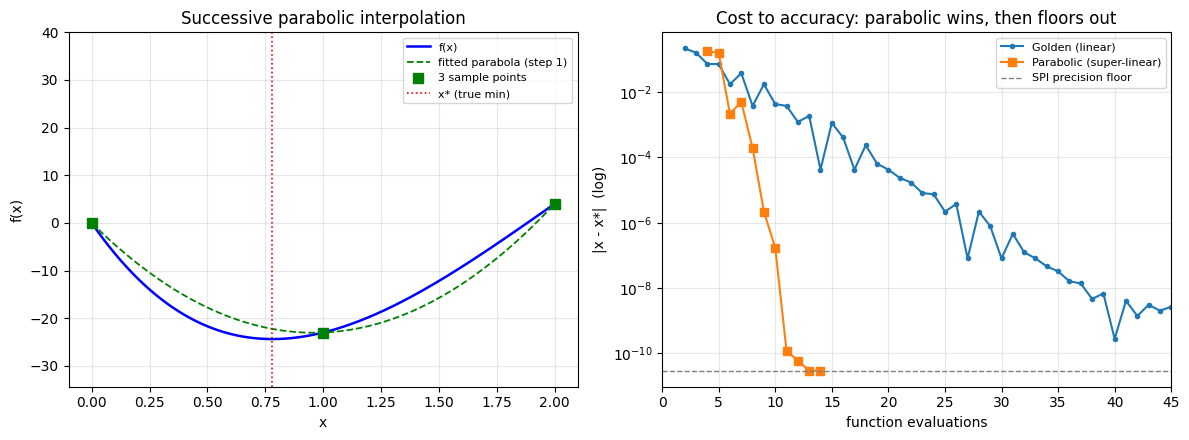

In [7]:
# 시각화: (좌) 포물선 보간 한 스텝,  (우) 오차 vs 함수평가 (golden vs SPI, 바닥 포함)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

xx = np.linspace(0, 2, 400)
ax[0].plot(xx, f(xx), 'b-', lw=1.8, label='f(x)')
x0, x1, x2 = 0.0, 1.0, 2.0
A = np.array([[x0**2, x0, 1], [x1**2, x1, 1], [x2**2, x2, 1]], float)
coef = np.linalg.solve(A, [f(x0), f(x1), f(x2)])
ax[0].plot(xx, np.polyval(coef, xx), 'g--', lw=1.3, label='fitted parabola (step 1)')
ax[0].plot([x0, x1, x2], [f(x0), f(x1), f(x2)], 'gs', ms=7, label='3 sample points')
ax[0].axvline(XSTAR, color='r', ls=':', lw=1.2, label='x* (true min)')
ax[0].set_ylim(f(XSTAR)-10, 40); ax[0].set_xlabel('x'); ax[0].set_ylabel('f(x)')
ax[0].set_title('Successive parabolic interpolation'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

gnf = [t[0] for t in tg];  ger = [max(t[1],1e-17) for t in tg]
pnf = [t[0] for t in trace_p]; per = [max(t[1],1e-17) for t in trace_p]
ax[1].semilogy(gnf, ger, 'o-', ms=3, label='Golden (linear)')
ax[1].semilogy(pnf, per, 's-', ms=6, label='Parabolic (super-linear)')
ax[1].axhline(floor_err, color='gray', ls='--', lw=1, label='SPI precision floor')
ax[1].set_xlim(0, 45); ax[1].set_xlabel('function evaluations'); ax[1].set_ylabel('|x - x*|  (log)')
ax[1].set_title('Cost to accuracy: parabolic wins, then floors out')
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3, which='both')

plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **함수평가가 격감한다(초선형).** 같은 정확도에 도달하는 함수평가가 황금분할의 수십 회에서 SPI 의 십여 회 이하로 줄고, tol 을 조일수록 *배속(speedup)이 커진다* — 오차가 선형이 아니라 초선형(이론 order $1.32$)으로 떨어지기 때문. 도함수 없이 secant 류 속도를 내므로 Brent 법의 핵심 엔진이 된다.
2. **평탄한 최소의 정밀도 바닥.** SPI 오차는 약 $\sqrt{\varepsilon}$ 규모($\sim10^{-8}\!\sim\!10^{-11}$)에서 바닥에 부딪혀 더 내려가지 않는다. 최소 근방에서 $f$ 가 *평탄*($f\approx f^\*+\tfrac12 f''\Delta x^2$)해 세 함수값이 반올림 안에서 구분되지 않기 때문 — 위치 정밀도의 절반(자릿수)을 잃는다. 이는 *도함수를 쓰지 않는 모든* 최소화법의 공통 한계다.
3. **안전망이 없다.** 세 점이 거의 일직선이면 분모$\approx0$ 로 꼭짓점이 폭주하고, 곡률이 음수면 *최대점*으로 끌린다. 단봉성을 강제하는 황금분할의 가드가 SPI 엔 없다 — 실전에선 **golden + parabolic 하이브리드**(Brent)로 결합한다.

> **결론**: 연속 포물선 보간은 도함수 없이 *초선형*으로 황금분할보다 훨씬 적은 함수평가로 수렴하지만, *평탄한 최소* 탓에 정밀도가 $\sqrt{\varepsilon}$ 바닥에 묶이고 단봉 가드가 없어 단독 사용은 불안정하다.

**다음 문제로 연결**: Problem 3 의 **Newton 최소화**는 도함수를 써서 $f'(x)=0$(평탄하지 않음)을 풀므로 *2차 수렴 + 기계정밀도*를 얻는다. 대신 도함수 2개가 필요하고 전역성이 없다 — 세 방법의 trade-off 를 종합한다.